## Run_QLC

This code solves the QLC problem in Cartesian space, Fourier space, and nondimensionalized space. Parameters include:
- $\overline N$, and $N^*$ (atomistic-level characteristics of the ice QLL thicknesses)
- $\sigma_o$ (difference in equilibrium supersaturation between microsurfaces I and II)
- $h_{pr}$ (thickness of a prismatic facet monolayer)
- $D_{surf}$ (surface diffusion coefficient of the QLL)
- $\nu_{kin}$ (kinetic velocity -- the rate at which water vapor strikes the surface)
- $L$ (physical length of the facet surface)
- $nx_{crystal}$ (number of discrete points used to represent the surface)
- $L$ (crystal dimension)
- $\sigma_{I,corner}$ (imposed supersaturation at the facet corner)
- $c_r$ (relative reduction in supersaturation at facet centers relative to corners, in fraction and %)
- $\tau_{eq}$ (time constant for ice/QLL freezing/thawing) (same as $t_{eq}$)

In [2]:
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import numpy as np
import matplotlib.pylab as plt
from time import time

import sys
import QLCstuff as QLC
import importlib  # Import the importlib module (importlib.reload(QLC) reload it)
# import f90nml

In [3]:
%matplotlib inline
ticklabelsize = 15
linewidth = 1
fontsize = 15
titlefontsize = 8
markersize = 10

# Constants
R = AssignQuantity(8.314462618,'J /mol / kelvin')
M_H2O = AssignQuantity(18.015,'g/mol')
rho_ice = AssignQuantity(0.917,'g/cm^3')

### Parameters defining the system and run-time

In [5]:
inputfile = "GI parameters - Table 1.nml"

sigmaI_corner, sigma0, c_r, sigmaI_QLC, Nbar, Nstar, h_layer, D, nu_kin, L, nx_crystal, t_eq, x_QLC, DoverL2pi2, Doverdeltax2 = \
    QLC.get_system_parameters(inputfile, AssignQuantity)

odemethod, tkeep_1Darr, Ntot_init_1D, NQLL_init_1D = \
    QLC.get_runtime_parameters(inputfile, nx_crystal, Nstar, Nbar, AssignQuantity)



Using parameter file GI parameters - Table 1.nml ...
sigmaI_corner = 22 percent
sigma0 = 20 percent
c_r = 0.2 percent
Nbar 1
Nstar 0.1
h_layer = 0.37 nanometer
D = 0.0002 micrometer ** 2 / microsecond
nu_kin = 0.264 / microsecond
L = 50 micrometer
nx (crystal) = 501
t_eq = 1.5 microsecond
Spacing of points on the ice surface = 0.20000000000000284 micrometer
omega_kin = 0.396 dimensionless

Using parameter file GI parameters - Table 1.nml ...
runtime = 300 millisecond
odemethod = RK45
This is a run from time 0.0 millisecond to 300.0 millisecond
dt = 6122.448979591837 microsecond


In [6]:
# Label for graphs
title_params = \
        "{:.0f}".format(L.magnitude)+' '+str(L.units)+\
        ", "+np.format_float_scientific(D.magnitude,precision=2)+" "+str(D.units)+\
        "\n"+\
        "{:.0f}".format(nu_kin.magnitude)+' '+str(nu_kin.units)+\
        "\n"+\
        "{:.3f}".format(sigmaI_corner.magnitude)+' '+str(sigmaI_corner.units)+\
        ", "+"{:.1f}".format(t_eq.magnitude)+' '+str(t_eq.units)+\
        ", "+"{:.3f}".format(c_r.to('percent').magnitude)+'%'+\
        ", "+odemethod+\
        "\n"

### Run the scenario in Cartesian space

0.22 dimensionless 0.22 0.2
10 % elapsed time is 0.588 minutes
20 % elapsed time is 1.093 minutes
30 % elapsed time is 1.603 minutes
40 % elapsed time is 2.113 minutes
50 % elapsed time is 2.625 minutes
60 % elapsed time is 3.141 minutes
70 % elapsed time is 3.652 minutes
80 % elapsed time is 4.168 minutes
90 % elapsed time is 4.678 minutes
100% done
status =  0
message =  The solver successfully reached the end of the integration interval.
['message', 'nfev', 'njev', 'nlu', 'sol', 'status', 'success', 't', 't_events', 'y', 'y_events']


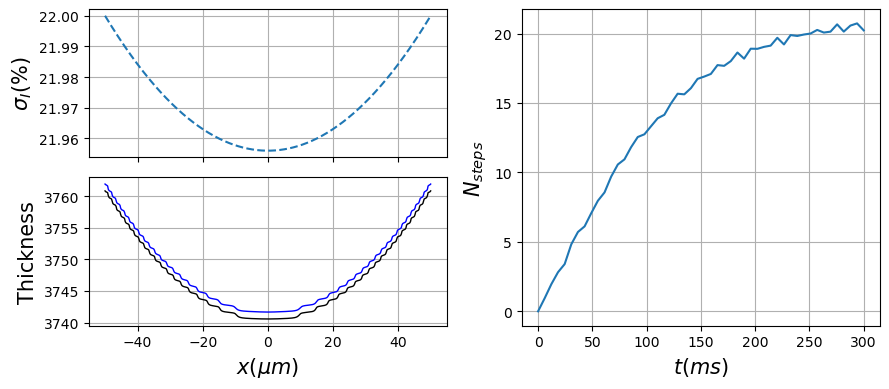

In [8]:
# Run the simulation 
Ntotkeep_1D, NQLLkeep_1D = QLC.run_f1d(\
           NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
           Nbar, Nstar, sigma0, nu_kin, Doverdeltax2, t_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod=odemethod)
Nicekeep_1D = Ntotkeep_1D-NQLLkeep_1D

# Graphical output
# g_ice_QLC = QLC.report_1d_growth_results(\
#         x_QLC,tkeep_1Darr,NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,h_layer, \
#         graphics=True,title_params=title_params)
fig = QLC.report_1d_growth_results_with_sigma(\
        x_QLC,tkeep_1Darr.to('millisecond'),NQLLkeep_1D,Ntotkeep_1D,Nicekeep_1D,sigmaI_QLC.to('percent'))

### Run the scenario in FT space (should look a lot like the above)

10 % elapsed time is 0.254 minutes
20 % elapsed time is 0.472 minutes
30 % elapsed time is 0.693 minutes
40 % elapsed time is 0.914 minutes
50 % elapsed time is 1.135 minutes
60 % elapsed time is 1.364 minutes
70 % elapsed time is 1.592 minutes
80 % elapsed time is 1.814 minutes
90 % elapsed time is 2.035 minutes
100% done
status =  0
message =  The solver successfully reached the end of the integration interval.
['message', 'nfev', 'njev', 'nlu', 'sol', 'status', 'success', 't', 't_events', 'y', 'y_events']


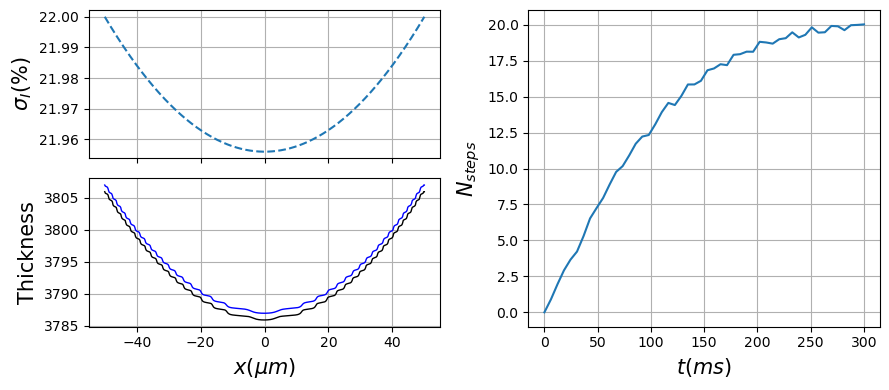

In [10]:
# Run the simulation
Ntotkeep_1D_FT, NQLLkeep_1D_FT = QLC.run_f1d_FT(\
           NQLL_init_1D,Ntot_init_1D,tkeep_1Darr,\
           Nbar, Nstar, sigma0, nu_kin, DoverL2pi2, t_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod='RK45') # RK45 allows integration of complex functions (but LSODA does not)
Nicekeep_1D_FT = Ntotkeep_1D_FT - NQLLkeep_1D_FT

# Graphical output
# g_ice_QLC_FT = QLC.report_1d_growth_results(\
#         x_QLC,tkeep_1Darr,NQLLkeep_1D_FT,Ntotkeep_1D_FT,Nicekeep_1D_FT,h_layer, \
#         graphics=True,title_params=title_params)
fig = QLC.report_1d_growth_results_with_sigma(\
    x_QLC,tkeep_1Darr.to('millisecond'),NQLLkeep_1D_FT,Ntotkeep_1D_FT,Nicekeep_1D_FT,sigmaI_QLC.to('percent'))

### Run the scenario in nondimensional coordinates (should look a lot like the above)

chi_QLC [-2886.751345948129 -2875.2043405643362 -2863.6573351805437 -2852.110329796751 -2840.563324412959] dimensionless
dchi 11.547005383792566 dimensionless
taukeep_1Darr [0.0 4081.6326530612246 8163.265306122449 12244.897959183674 16326.530612244898] dimensionless
tau_eq 1.0 dimensionless
omega_kin 0.396 dimensionless
Doverdeltachi2 0.007499999999999934 dimensionless
0.22 dimensionless 0.22 0.2
10 % elapsed time is 0.594 minutes
20 % elapsed time is 1.101 minutes
30 % elapsed time is 1.610 minutes
40 % elapsed time is 2.119 minutes
50 % elapsed time is 2.628 minutes
60 % elapsed time is 3.139 minutes
70 % elapsed time is 3.650 minutes
80 % elapsed time is 4.160 minutes
90 % elapsed time is 4.672 minutes
100% done
status =  0
message =  The solver successfully reached the end of the integration interval.
['message', 'nfev', 'njev', 'nlu', 'sol', 'status', 'success', 't', 't_events', 'y', 'y_events']


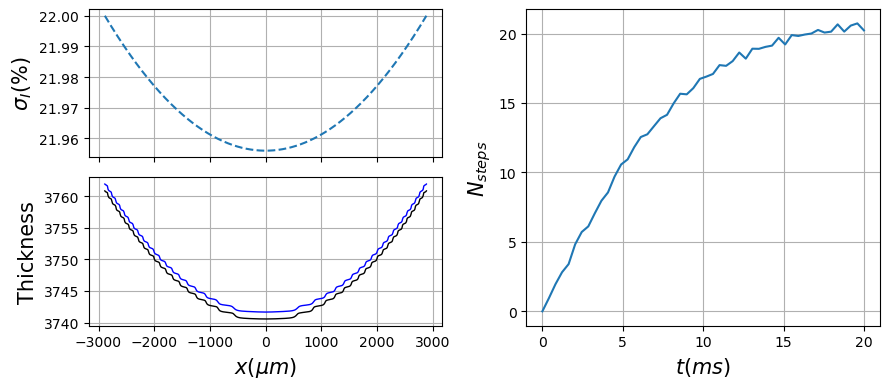

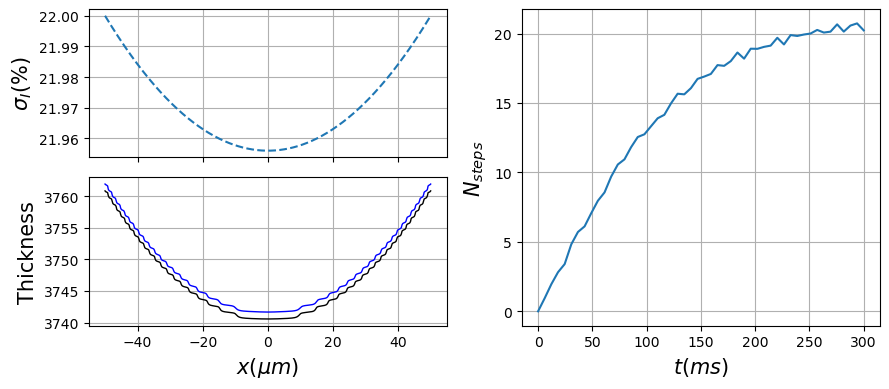

In [12]:
# Get nondimensionalized variables
chi_QLC = x_QLC/(D*t_eq)**0.5; print('chi_QLC',chi_QLC[0:5])
dchi = chi_QLC[1]-chi_QLC[0]; print('dchi',dchi)
taukeep_1Darr = tkeep_1Darr/t_eq; print('taukeep_1Darr',taukeep_1Darr[0:5])
tau_eq = t_eq/t_eq; print('tau_eq',tau_eq)
omega_kin = t_eq*nu_kin; print('omega_kin',omega_kin)
D_nondim = AssignQuantity(1,'dimensionless')
Doverdeltachi2 = D_nondim/dchi**2; print('Doverdeltachi2',Doverdeltachi2)

# Runs the simulation
Ntotkeep_1D_nondim, NQLLkeep_1D_nondim = QLC.run_f1d(\
           NQLL_init_1D,Ntot_init_1D,taukeep_1Darr,\
           Nbar, Nstar, sigma0, omega_kin, Doverdeltachi2, tau_eq, sigmaI_QLC,\
           AssignQuantity,\
           verbose=0, odemethod=odemethod)
Nicekeep_1D_nondim = Ntotkeep_1D_nondim-NQLLkeep_1D_nondim

# This reports using nondimensionalized variables chi and tau (the unit labels are wrong, however)
fig = QLC.report_1d_growth_results_with_sigma(\
    chi_QLC,taukeep_1Darr.to('dimensionless')/1e4,NQLLkeep_1D_nondim,Ntotkeep_1D_nondim,Nicekeep_1D_nondim,sigmaI_QLC.to('percent'))

# This reports using the original variables x and t (easier to compare with the above, and the unit labels are correct)
fig = QLC.report_1d_growth_results_with_sigma(\
    x_QLC,tkeep_1Darr.to('ms'),NQLLkeep_1D_nondim,Ntotkeep_1D_nondim,Nicekeep_1D_nondim,sigmaI_QLC.to('percent'))